# P02 第四至六部分：描述统计、可视化与 CAPM

请先运行 `01_download.ipynb` 与 `02_clean.ipynb`。
本 Notebook 基于清洗后的数据完成：
- 描述性统计与可视化（图 1-5）
- CAPM 回归估计
- 宏观指标对股票收益率的影响（选做）

所有图形保存至 `output/` 目录

In [ ]:
from pathlib import Path
from datetime import datetime
import os
import time

import numpy as np
import pandas as pd

# ---------- 项目根目录 ----------
ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent
if not (ROOT / "data").exists():
    ROOT = Path(r"G:/ganlijie/ds_homework/dshw-p01")

START_DATE = "20200101"
END_DATE = datetime.now().strftime("%Y%m%d")

STOCK_LIST = [
    {"code": "601398", "name": "工商银行", "industry": "银行"},
    {"code": "600036", "name": "招商银行", "industry": "银行"},
    {"code": "002594", "name": "比亚迪", "industry": "汽车"},
    {"code": "601633", "name": "长城汽车", "industry": "汽车"},
    {"code": "000002", "name": "万科A", "industry": "房地产"},
    {"code": "600519", "name": "贵州茅台", "industry": "白酒"},
    {"code": "000858", "name": "五粮液", "industry": "白酒"},
    {"code": "601857", "name": "中国石油", "industry": "能源"},
    {"code": "600941", "name": "中国移动", "industry": "通讯"},
    {"code": "002352", "name": "顺丰控股", "industry": "物流"},
]

DIRS = {
    "stock": ROOT / "data" / "stock",
    "index": ROOT / "data" / "index",
    "macro": ROOT / "data" / "macro",
    "finance": ROOT / "data" / "finance",
    "clean": ROOT / "data" / "clean",
    "combined": ROOT / "data" / "combined",
    "output": ROOT / "output",
}
LOG_FILE = ROOT / "download_log.txt"
COMBINED_CSV = DIRS["combined"] / "combined_data.csv"
STOCK_CLEAN_CSV = DIRS["clean"] / "stock_clean.csv"
STOCK_CLEAN_PARQUET = DIRS["clean"] / "stock_clean.parquet"
FIN_DB = DIRS["combined"] / "fin_data.db"
RF_DAILY = 0.02 / 252
TRADING_DAYS = 252
FINANCE_INDICATORS = ["净资产收益率(ROE)", "销售净利率"]

def setup_directories():
    for p in DIRS.values():
        p.mkdir(parents=True, exist_ok=True)

def log_download(status, tag, detail=""):
    ts = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    line = f"[{ts}] {status:<7} {tag}"
    if detail:
        line += f"  {detail}"
    with open(LOG_FILE, "a", encoding="utf-8") as f:
        f.write(line + "\n")

def stock_csv_path(code):
    return DIRS["stock"] / f"stock_{code}.csv"

def index_csv_path(code):
    return DIRS["index"] / f"index_{code}.csv"

setup_directories()

try:
    from IPython.display import display
except ImportError:
    display = print

print("项目根目录:", ROOT.resolve())

import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import norm, pearsonr, skew, kurtosis

plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

INDUSTRY_MAP = {s["code"]: s["industry"] for s in STOCK_LIST}
NAME_MAP = {s["code"]: s["name"] for s in STOCK_LIST}
OUT = DIRS["output"]
OUT.mkdir(parents=True, exist_ok=True)

def load_clean_stock():
    df = pd.read_csv(STOCK_CLEAN_CSV, parse_dates=["date"], dtype={"code": str})
    df["code"] = df["code"].str.zfill(6)
    return df

def load_hs300_returns():
    idx = pd.read_csv(index_csv_path("000300"), parse_dates=["date"]).sort_values("date")
    r = np.log(idx["close"] / idx["close"].shift(1))
    r.index = idx["date"]
    return r.dropna()

def descriptive_stats(long_df):
    rows = []
    for item in STOCK_LIST:
        code = item["code"]
        r = long_df[long_df["code"] == code].sort_values("date")["return"].dropna()
        cum = (1 + r).cumprod()
        dd = (cum - cum.cummax()) / cum.cummax()
        rows.append({
            "股票": NAME_MAP[code], "行业": item["industry"],
            "年化均值": r.mean() * TRADING_DAYS,
            "年化波动率": r.std() * np.sqrt(TRADING_DAYS),
            "偏度": skew(r), "峰度": kurtosis(r), "最大回撤": dd.min(),
        })
    return pd.DataFrame(rows)

def capm_regression(long_df):
    rm = load_hs300_returns()
    rows = []
    for item in STOCK_LIST:
        code = item["code"]
        ri = long_df[long_df["code"] == code].set_index("date")["return"].dropna()
        aligned = pd.concat([ri, rm], axis=1, join="inner").dropna()
        aligned.columns = ["ri", "rm"]
        y = aligned["ri"] - RF_DAILY
        x = aligned["rm"] - RF_DAILY
        model = sm.OLS(y, sm.add_constant(x)).fit()
        ci = model.conf_int().loc["rm"]
        rows.append({
            "股票": NAME_MAP[code], "行业": item["industry"], "code": code,
            "alpha": model.params["const"], "alpha_p": model.pvalues["const"],
            "beta": model.params["rm"], "beta_ci_low": ci[0], "beta_ci_high": ci[1],
            "r2": model.rsquared,
        })
    return pd.DataFrame(rows)

def monthly_macro_regression(long_df, indicator="m2"):
    macro = pd.read_csv(DIRS["macro"] / f"macro_{indicator}.csv", parse_dates=["date"])
    macro["month"] = macro["date"].dt.to_period("M").astype(str)
    df = long_df.copy()
    df["month"] = df["date"].dt.to_period("M").astype(str)
    mret = df.groupby(["code", "month"])["return"].sum().reset_index()
    merged = mret.merge(macro[["month", "value"]], on="month", how="inner")
    rows = []
    for item in STOCK_LIST:
        code = item["code"]
        sub = merged[merged["code"] == code]
        if len(sub) < 12:
            continue
        model = sm.OLS(sub["return"], sm.add_constant(sub["value"])).fit()
        rows.append({
            "股票": NAME_MAP[code], "行业": item["industry"],
            "gamma": model.params["value"], "gamma_p": model.pvalues["value"],
        })
    return pd.DataFrame(rows)

long_df = load_clean_stock()
print("清洗数据行数:", len(long_df))
print("分析函数已定义")

项目根目录: G:\ganlijie\ds_homework\dshw-p01
清洗数据行数: 14920
分析函数已定义


## 4.1 描述性统计

计算 10 只股票日对数收益率的描述性统计，包括年化均值、年化波动率、偏度、峰度和最大回撤。

In [ ]:
desc = descriptive_stats(long_df)
display(desc.style.format({'年化均值':'{:.2%}','年化波动率':'{:.2%}','最大回撤':'{:.2%}'}))

,股票,行业,年化均值,年化波动率,偏度,峰度,最大回撤
0,工商银行,银行,5.38%,10.20%,0.492012,6.513862,-14.39%
1,招商银行,银行,3.20%,23.19%,0.261383,3.549097,-48.42%
2,比亚迪,汽车,29.23%,42.68%,0.309921,2.105503,-55.73%
3,长城汽车,汽车,11.40%,40.81%,0.468333,2.312345,-75.42%
4,万科A,房地产,-17.85%,23.01%,0.585680,3.783620,-71.73%
5,贵州茅台,白酒,4.99%,25.58%,0.199292,3.523436,-51.12%
6,五粮液,白酒,-2.80%,31.59%,0.008197,3.383209,-73.49%
7,中国石油,能源,10.43%,19.36%,0.247030,5.476218,-22.99%
8,中国移动,通讯,17.03%,23.48%,0.648783,5.595191,-17.04%
9,顺丰控股,物流,0.88%,30.74%,0.403022,3.781089,-74.10%


### 图1 归一化收盘价

以 2020-01-01 = 1 为基准，展示 10 只股票的归一化收盘价走势，并叠加沪深 300。图例按行业分组着色。

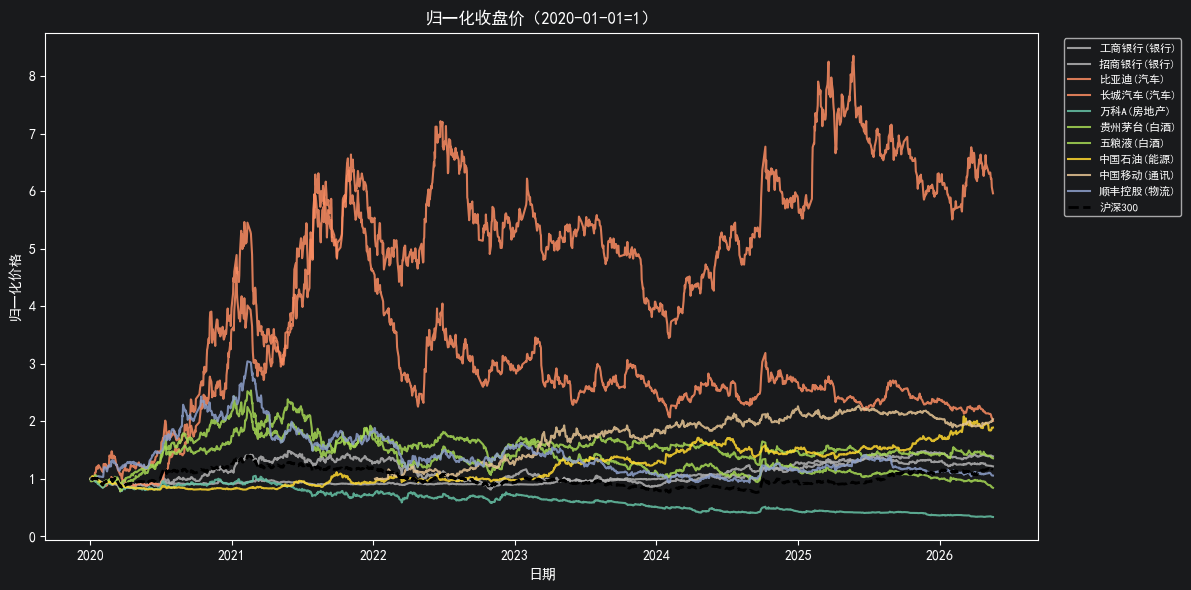

In [ ]:
idx = pd.read_csv(index_csv_path('000300'), parse_dates=['date'])
base = pd.Timestamp('2020-01-01')
fig, ax = plt.subplots(figsize=(12, 6))
inds = sorted(set(INDUSTRY_MAP.values()))
cmap = dict(zip(inds, plt.cm.Set2(np.linspace(0, 1, len(inds)))))
for item in STOCK_LIST:
    sub = long_df[(long_df['code']==item['code']) & (long_df['date']>=base)].sort_values('date')
    ax.plot(sub['date'], sub['close']/sub['close'].iloc[0],
            label=f"{item['name']}({item['industry']})", color=cmap[item['industry']], alpha=0.85)
hs = idx[idx['date']>=base]
ax.plot(hs['date'], hs['close']/hs['close'].iloc[0], 'k--', lw=2, label='沪深300')
ax.set_title('归一化收盘价（2020-01-01=1）'); ax.set_xlabel('日期'); ax.set_ylabel('归一化价格')
ax.legend(bbox_to_anchor=(1.02,1), fontsize=8); plt.tight_layout()
fig.savefig(OUT/'fig1_normalized_price.png', dpi=150, bbox_inches='tight'); plt.show()

解读：

这张图以2020年1月1日为基准，将十只代表性个股与沪深300指数的收盘价归一化为1，时间跨度从2020年初延续至2026年初。这张图是一部中国产业结构变迁的"资本市场编年史"——新能源的狂飙、核心资产的幻灭、房地产的塌陷与传统行业的逆袭，在短短六年间的价格轨迹中展现得淋漓尽致。

一、总体格局：从"同涨同跌"到"极致分化"
2020年初疫情冲击后的前三个月，所有资产几乎同步下探至基准线附近，呈现出典型的系统性风险特征。然而自2020年下半年起，各条曲线迅速分道扬镳。到了2026年初，表现最好的资产价格已超过基准的八倍，而最差的资产仅剩不到三成。这种十倍级别的收益差距，在成熟市场中极为罕见，充分说明这六年是中国经济新旧动能转换阵痛期的集中映射——资本市场已不再是对宏观经济的"平均投票"，而是对产业趋势的"极端定价"。

二、新能源赛道：高增长的奖赏与周期的残酷
图中最为瞩目的当属比亚迪，其价格曲线如一匹脱缰野马，从基准1最高攀升至超过8，尽管期间历经数次幅度超过40%的剧烈回调，但最终仍稳居收益榜首。这完美诠释了产业趋势投资的"戴维斯双击"逻辑：2020年至2025年恰逢中国新能源汽车渗透率从5%飙升至超过50%的史诗级进程，比亚迪作为垂直整合龙头，同时享受了销量爆发带来的盈利增长和估值重构。

然而，同为汽车板块的长城汽车则呈现出另一番景象。它在2021年也曾一度涨至3倍左右，但此后便进入漫长的高位震荡与回落通道，最终稳定在2倍附近。两者的分化揭示了一个关键规律：同一赛道中的龙头企业与非龙头企业，其股价韧性的差距远大于盈利差距。比亚迪凭借电池自研、品牌矩阵和规模效应构建了护城河，市场愿意给予其"穿越周期"的估值溢价；而长城作为追赶者，在价格战白热化阶段更容易遭受利润侵蚀与估值压缩的双重打击。

从经济周期角度看，汽车板块的波动轨迹也映射了库存周期与政策周期的叠加。2021年的高点对应购置税减免与新能源补贴的政策红利期，而2024年至2025年的震荡则反映了行业从"增量博弈"转向"存量厮杀"的残酷现实。

三、白酒板块：核心资产叙事的高潮与退潮
贵州茅台与五粮液在2020年至2021年的核心资产牛市中表现亮眼，双双涨至2.5倍至3倍区间。这一阶段的上涨背后，是外资流入、公募基金发行潮与"永续增长"叙事的三重共振。高端白酒因其商业模式的稀缺性（轻资产、高毛利、强定价权）被赋予了类似消费股的估值溢价。

但2022年之后，两条曲线明显陷入高位震荡并逐级回落，到2026年初已回调至1.5倍至2倍区间。这一走势并非偶然：随着人口结构变化、商务消费场景收缩以及渠道库存压力显现，高端白酒的量价齐升逻辑出现裂痕。茅台凭借其绝对龙头地位展现出更强的抗跌性，价格中枢始终维持在2倍左右；而五粮液的回落幅度更大，说明次高端白酒在消费分级趋势下承受了更大的竞争压力。这与前文ROE分析中五粮液盈利能力下滑的判断形成了交叉验证。

四、房地产：趋势性价值毁灭的典型案例
万科A的价格曲线是全场唯一一条几乎单向下行的轨迹，从基准1一路滑落至0.3以下，跌幅超过70%。这一触目惊心的走势，是中国房地产行业从"高周转高杠杆"模式向"去杠杆去库存"转型的最直接写照。

2020年之前，万科作为行业标杆享有"永续经营"的估值假设。但随着"三道红线"政策的出台、销售面积的系统性下滑以及房价预期的逆转，房地产企业的资产负债表遭受了双重挤压：资产端存货减值、负债端融资困难。更为严峻的是，这一下跌趋势几乎没有出现过像样的反弹，说明市场已经将该行业从"周期性波动"重新定义为"结构性衰退"。对于投资者而言，万科的案例提供了血淋淋的教训：当行业的底层商业逻辑发生永久性改变时，均值回归的信仰将成为价值陷阱。

五、能源与通讯：传统行业的"第二春"
中国石油和中国移动的轨迹颇具启发性。中石油在2020年一度跌破基准（油价暴跌叠加疫情冲击），但此后稳步回升，最终站稳在1.5倍至2倍区间。这一逆袭的背后是国际油价中枢上移（地缘政治冲突导致供给收缩）与国企改革深化（降本增效、分红率提升）的共同作用。

中国移动则展现出更为稳健的"慢牛"特征，价格从基准1持续攀升至接近2倍，波动极小。这反映了公用事业型资产的防御性魅力：在经济增长放缓、利率下行的宏观环境中，稳定的现金流和高股息率对机构资金的吸引力显著增强。尤其值得注意的是，移动在2022年之后与沪深300指数走出了明显的剪刀差——当大盘陷入震荡时，它反而加速上涨，这正是"类债券"资产在风险规避环境下的典型表现。

六、银行与物流：平淡中的结构性差异
工商银行和招商银行的价格曲线几乎贴地爬行，六年累计收益仅在20%至50%之间，勉强跑赢或持平于沪深300指数。这背后是整个银行业面临的净息差收窄困局：在利率市场化与"金融让利实体"的政策导向下，银行的盈利能力被系统性压缩。工商银行作为国有大行，其股价波动极小，几乎成为一只"准固定收益"产品；招商银行虽有一定的零售业务溢价，但在地产风险暴露和财富管理收入下滑的压力下，同样未能走出独立行情。

顺丰控股的轨迹则充满了戏剧性：2021年初一度冲至3倍高点，但随后深度回调，最终回落至1.5倍左右。这一"过山车"行情反映了快递行业在疫情期间的特殊红利（线上消费激增）消退后，产能过剩与价格战对企业盈利能力的持续侵蚀。顺丰试图通过国际业务和供应链延伸寻找第二增长曲线，但市场对其转型成效仍持审慎态度。

七、宏观映射与投资启示
将各条曲线叠加观察，可以发现一条清晰的宏观经济映射脉络：2020年至2021年是流动性宽松与消费复苏驱动的"普涨期"，几乎所有资产都有表现；2022年之后则是产业逻辑主导的分化期，新能源、传统能源和通讯基建持续获得资金青睐，而地产、白酒和部分消费服务则进入漫长的估值消化阶段。

对于投资者而言，这张图传递了几条关键启示。

第一，长期持有的前提是选对赛道。如果在2020年初等权重买入这十只股票并持有六年，组合的绝对收益可能相当平庸，因为万科的巨额亏损会严重拖累整体表现。但若能识别出新能源与传统能源的结构性机会，收益将呈指数级放大。

第二，波动率本身并非敌人，方向才是。比亚迪的曲线波动极大，但方向向上；万科的波动相对较小，但方向向下。在经济转型期，投资者更应关注产业趋势的方向性判断，而非短期价格的起伏。

第三，防御性资产在特定宏观环境中具有配置价值。当市场从"成长叙事"转向"现金流叙事"时，中国移动和中国石油这类低估值、高股息资产的性价比会显著提升。2024年至2025年，这类资产持续跑赢大盘，正是市场对经济不确定性的理性回应。

八、结语
这张归一化价格图用最直观的方式证明了：在产业结构剧烈变动的时代，资本市场的分化远比市场的整体涨跌更重要。比亚迪的八倍涨幅与万科的七成跌幅，并非随机漫步的结果，而是中国经济从"地产—基建"驱动向"新能源—高端制造"驱动转型的必然映射。这种极致分化仍将持续，直到新的产业均衡形成。投资者若仍抱有"普涨普跌"的旧思维，将在未来的结构性行情中持续迷失方向。

### 图2 日收益率分布

10 只股票收益率分面直方图（2 行 × 5 列），每个子图叠加正态分布曲线，并标注均值和标准差。

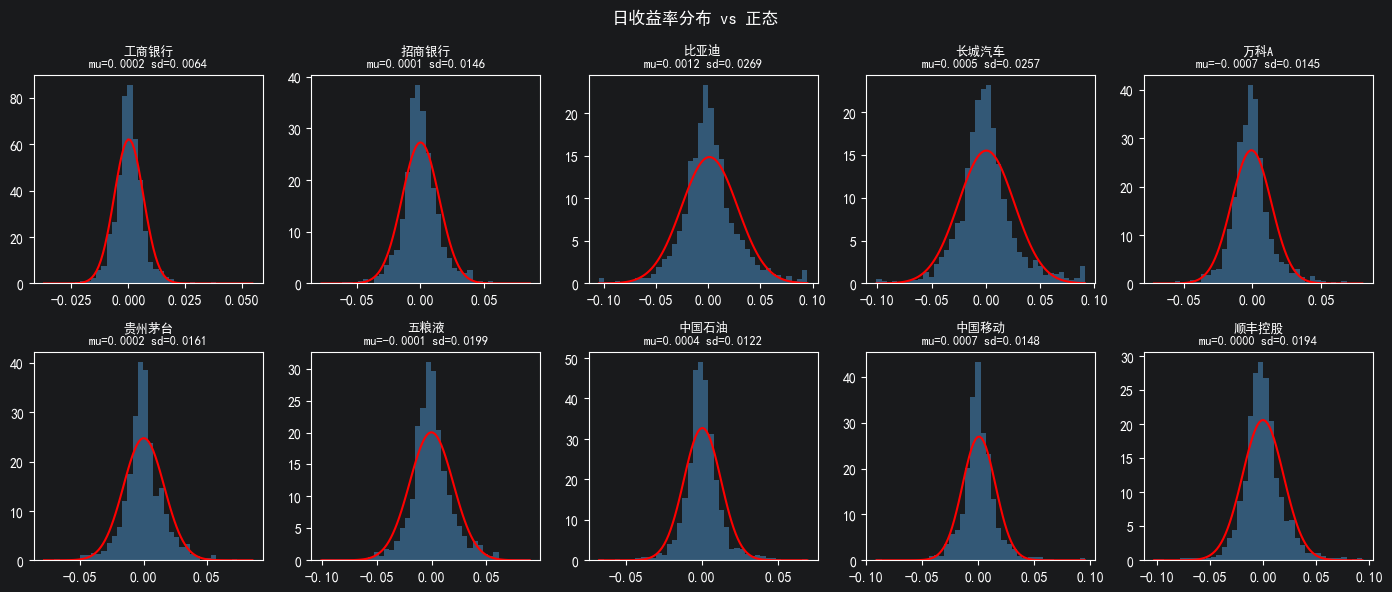

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, item in enumerate(STOCK_LIST):
    r = long_df[long_df['code']==item['code']]['return'].dropna()
    ax = axes.ravel()[i]
    ax.hist(r, bins=40, density=True, alpha=0.6, color='steelblue')
    mu, sd = r.mean(), r.std()
    x = np.linspace(r.min(), r.max(), 100)
    ax.plot(x, norm.pdf(x, mu, sd), 'r-')
    ax.set_title(f"{item['name']}\nmu={mu:.4f} sd={sd:.4f}", fontsize=9)
plt.suptitle('日收益率分布 vs 正态'); plt.tight_layout()
fig.savefig(OUT/'fig2_return_dist.png', dpi=150); plt.show()

解读：

这张图展示了十只代表性个股日收益率的直方分布与正态分布拟合的对比，横轴为日收益率，纵轴为频率密度，红色曲线是基于样本均值和标准差生成的理论正态分布。我从中读出了三层关键信息：市场并非正态世界、个股风险结构高度分化、尾部风险被系统性低估。

一、核心特征：尖峰厚尾的普遍性
十只股票的日收益率分布呈现出高度一致的尖峰厚尾（Leptokurtosis）特征。直观上看，所有直方图在零收益附近的峰值都显著高于红色正态曲线，这意味着股价在大概率时间里只发生微小波动，"不涨不跌"或微涨微跌是最常见的状态。与此同时，分布两侧尾部的柱形也明显高于正态分布的理论预测，说明极端涨跌事件的发生频率远超正态假设所能解释的范围。

现代资产定价理论的许多经典模型——如马科维茨均值方差模型、布莱克斯科尔斯期权定价公式——都隐含假设收益率服从正态分布。然而这张图有力地证伪了该假设：如果投资者基于正态分布来估算风险价值（VaR）或构造对冲策略，将会系统性地低估极端损失的概率。这正是2008年金融危机中许多量化模型失效的微观根源。

二、个股分化：三类风险画像
从标准差这一维度观察，十只股票可以清晰划分为三个风险层级。

第一类是低波动防御型，以工商银行为代表，日收益率标准差仅为0.0064，约为全样本最低。其分布最为"瘦窄"，极端收益事件极少。这反映了大型国有银行作为系统性重要金融机构的特殊地位——股价受政策托底预期、稳定股息策略和有限的交易投机性共同支撑，日波动被显著压缩。中国石油的标准差为0.0122，也属于这一阵营，但受国际油价脉冲影响，尾部较银行略厚。

第二类是中等波动蓝筹型，涵盖招商银行、贵州茅台、中国移动、万科A和顺丰控股，标准差集中在0.014至0.020之间。这些股票的基本面质地较好、机构覆盖度高，但交易活跃度也更高，因此波动大于银行，却远小于成长赛道。值得注意的是，万科A的日均收益为负值（-0.0007），是十只股票中唯一日收益为负的标的，这与房地产行业进入深度调整期、股价趋势性下行的基本面高度吻合。五粮液的日均收益也为微负（-0.0001），反映出次高端白酒面临的渠道压力。

第三类是高波动成长型，以比亚迪和长城汽车为代表，标准差分别高达0.0269和0.0257，约为工商银行的三至四倍。比亚迪的日均收益为0.0012，同样是全样本最高，说明高风险确实带来了正向风险补偿。这类股票的分布明显"扁平化"，零收益附近的峰值相对较低，但两侧尾部绵延更长——这意味着新能源汽车赛道的高景气预期与激烈的价格博弈交织，使得股价在任何交易日都可能因订单数据、政策传闻或竞争动态而出现剧烈重定价。

三、尾部风险的结构性差异
虽然所有股票都呈现尖峰厚尾，但尾部的对称性和厚度仍存在微妙差异。

工商银行和中国移动的分布几乎完全对称，正负尾部的厚度相当，说明其股价波动主要由系统性因素（大盘情绪、宏观流动性）驱动，缺乏个股层面的非对称冲击。这与它们作为大市值蓝筹、难以被单一资金操纵或消息冲击的特征相符。

相比之下，比亚迪、长城汽车的正尾部似乎略厚于负尾部，或者说负尾部的极端值更为离散。这暗示新能源汽车板块存在非对称的风险结构：行业处于渗透率快速提升的成长期，好消息（如销量超预期、技术突破）可能引发连续的涨停式反应，而坏消息（如价格战加剧、补贴退坡）虽然也会造成下跌，但幅度和频率相对可控。这种"涨多跌少"的非对称性在一定程度上解释了为何高波动成长股仍对风险偏好型投资者具有吸引力。

万科A的分布则呈现出另一番景象——其均值位于负区间，且分布虽然大致对称，但左侧尾部的极端负收益事件明显多于右侧。这再次印证了趋势性下跌资产的特殊风险：即便日波动绝对值不算最大，但负收益概率的持续累积会导致长期持有体验极差。

四、对投资实践的启示

首先，摒弃"正态思维"进行风险控制。如果使用基于正态分布的标准差来设定止损线或仓位上限，投资者将在极端行情下面临远超预期的损失。实践中应采用更贴近现实的分布假设——如t分布、稳定分布，或在VaR计算中引入压力测试和情景分析。

其次，低波动策略在中国A股具有实证支撑。工商银行的极低日波动并非个例，而是反映了特定类型资产的"低波动异象"。大量海外实证研究表明，低波动股票在长期中往往能获得与高波动股票相当甚至更高的经风险调整收益。对于保守型资金（如养老金、保险资金），将银行、能源等低波动蓝筹作为底仓，可以在控制回撤的同时获取稳定股息。

第三，成长股的"高波动税"不容忽视。比亚迪虽然日均收益最高，但其0.0269的标准差意味着单日涨跌幅超过5%的事件并不罕见。对于无法承受剧烈回撤的投资者，即便看好新能源汽车的长期前景，也应通过定投、期权保护或仓位控制来平滑路径波动，避免因短期极端波动而被迫在底部离场。

最后，趋势性下跌资产的"钝刀子"效应比高波动更危险。万科A的日标准差仅为0.0145，处于中等水平，但其日均收益为负，且长期趋势向下。这意味着投资者如果持有该资产，将面临"每天跌一点、积少成多"的慢性价值侵蚀。相比之下，高波动资产至少提供了正向的风险溢价补偿，而趋势性下跌资产则同时具备波动性和负收益双重毒性，是组合管理中最应优先剔除的标的。

五、总结
这张日收益率分布图以简洁而有力的方式揭示了中国A股市场的底层统计规律：收益率不是正态的、波动不是对称的、风险不是均匀的。工商银行代表了"稳"的极致，比亚迪代表了"进"的代价，万科A则代表了"退"的陷阱。对于专业投资者而言，理解这些分布形态的异质性，远比记住每只股票的平均收益更重要——因为均值是幻觉，分布才是真相。

### 图3 相关系数热力图

10 只股票日收益率的相关系数矩阵，按行业排序，标注具体数值。

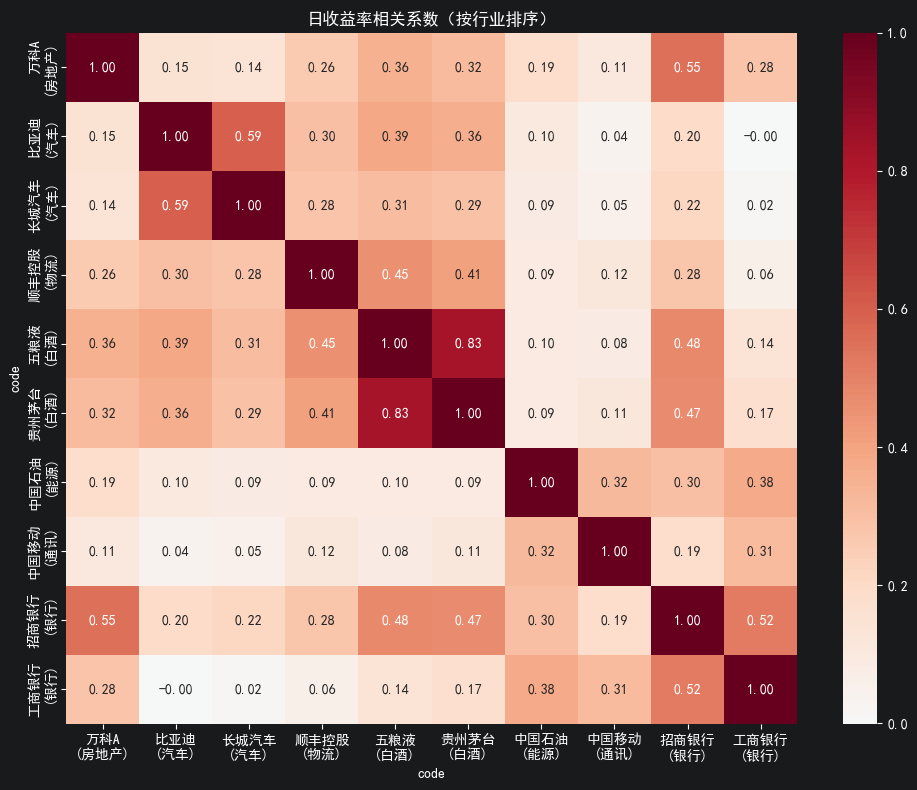

In [ ]:
order = sorted(STOCK_LIST, key=lambda x: (x['industry'], x['code']))
codes = [x['code'] for x in order]
corr = long_df.pivot(index='date', columns='code', values='return')[codes].corr()
labels = [f"{NAME_MAP[c]}\n({INDUSTRY_MAP[c]})" for c in codes]
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', xticklabels=labels, yticklabels=labels,
            cmap='RdBu_r', center=0, ax=ax)
ax.set_title('日收益率相关系数（按行业排序）'); plt.tight_layout()
fig.savefig(OUT/'fig3_corr_heatmap.png', dpi=150); plt.show()

解读：

日收益率相关系数热力图解读  
这张热力图呈现了十只代表性个股日收益率的Pearson相关系数矩阵，按房地产、汽车、物流、白酒、能源、通讯、银行七大行业聚类排列。从中可以清晰读出A股市场的板块同质化程度、风险传导路径以及分散化投资的有效性边界。

一、板块内部：白酒的"克隆效应"最为极端  
五粮液与贵州茅台的日收益相关系数高达0.83，这是全图最高的跨个股相关，远超其他组合。这一数值揭示了两个关键信息：其一，高端白酒的需求驱动因素高度一致，商务消费、礼品属性与渠道库存周期使两家企业面对相同的宏观温度；其二，更重要的是资金面的"核心资产"绑定——北向资金与公募基金将茅五视为同一类必选消费核心资产进行集中配置，交易行为高度趋同。持有茅台加五粮液，本质上是对同一风险敞口的两次暴露，分散风险的作用极为有限。

汽车板块内部，比亚迪与长城汽车的相关系数为0.59，属于中等偏强水平，反映出新能源汽车产业链的同向贝塔属性。但这一数值显著低于白酒龙头的0.83，说明汽车板块内部仍存在结构性分化空间，比亚迪的垂直整合模式与长城的差异化产品策略使得两者的盈利节奏并不完全一致，个股选择在该领域仍具价值。

银行板块中，招商银行与工商银行的相关系数为0.52，低于白酒但高于多数跨行业组合。这印证了银行股共享利率环境、信贷周期与监管政策等系统性驱动因素，但零售业务见长的招行与对公业务为主的工行在地产风险暴露和息差敏感性方面存在差异，因而未形成完全的同质化联动。

二、跨行业关联：地产—银行轴的风险共振  
万科A与招商银行的相关系数达到0.55，是全图最高的跨行业相关，甚至高于银行板块内部的工行—招行组合（0.52）。这一数据将房地产风险向金融系统的传导机制量化了：银行信贷资产质量与房地产景气度深度绑定，当万科股价下跌反映销售回款困难或债务违约风险上升时，市场会同步重估招行的地产相关敞口。值得注意的是，万科与工商银行的相关系数仅为0.28，明显低于与招行的0.55，这暗示招商银行在地产领域的客户结构或风险偏好与万科的关联度更高。

白酒龙头与招商银行的相关系数约为0.47至0.48，地产龙头与白酒龙头也有0.32至0.36的相关性。这些跨行业高相关的背后，并非基本面的直接关联，而是同一类机构资金的同步调仓行为。在2019年至2021年的核心资产牛市中，公募与外资将茅五、招行、万科等纳入同一套"中国优质资产"叙事框架；当宏观经济预期转向时，这些资金会同步减仓高估值蓝筹，导致原本基本面无关的股票出现同向波动。

三、能源与通讯：真正的"独立孤岛"  
中国石油、中国移动与绝大多数个股的相关性极低，多数低于0.15。例如，中国移动与比亚迪的相关系数仅0.04，几乎等同于随机波动；中国石油与五粮液的相关系数仅0.09。这印证了传统能源与公用事业类资产的防御性独立行情特征——它们的定价逻辑主要受国际油价、股息率、无风险利率等宏观变量驱动，与消费、地产、成长股的资金博弈圈子相互隔离。对于追求组合分散化的投资者而言，这两类资产是降低组合波动率的有效工具。

四、物流的"中间态"与机构的"隐形集群"  
顺丰控股与白酒的相关系数为0.41至0.45，与银行的相关系数为0.28，呈现出介于消费与金融之间的联动特征。这符合顺丰的业务属性——既受益于消费复苏带来的电商快递量增长，又受企业景气度影响，因此与消费龙头和金融龙头均保持中等相关性。

从全局视角看，白酒与地产—银行轴构成了A股最大的"隐形风险集群"。这些股票表面分属不同行业，但在机构持仓层面高度绑定。一旦宏观流动性收紧或外资撤离，可能出现无差别的同步杀跌。2022年后的"去抱团"过程中，这种相关性虽有所弱化，但仍显著高于随机水平。

五、投资组合构建的实务建议   
基于上述相关系数结构，不同组合策略的风险分散效果差异显著。

白酒加白酒（茅加五）的相关系数为0.83，近乎同一资产，仓位叠加等于对单一风险敞口加杠杆，不构成有效分散。地产加银行（万科加招行）的相关系数为0.55，呈现显著的风险共振特征，在地产下行周期中应避免同时超配，否则将面临地产风险向金融系统传导的双重冲击。

能源或通讯加任何成长板块的相关系数普遍低于0.15，近乎独立。中国石油和中国移动是最佳的风险分散工具，可有效降低投资组合的整体波动率。汽车内部（比亚迪加长城）的相关系数为0.59，属于中等相关水平，投资者可在保留新能源汽车行业敞口的同时，适度进行个股间的轮动切换，捕捉结构性阿尔法机会。

六、结论  
这张热力图揭示了A股市场从"普涨普跌"向"结构性分化"演进过程中的中间态——板块内部高度同质化，但板块间已出现显著割裂。白酒与地产—银行轴构成了最大的隐性联动风险，能源与通讯则是真正的组合稳定器。相关系数是动态而非静态的，在极端行情中所有资产的相关系数会趋向1，分散化效应将暂时失效。投资者应定期滚动测算相关系数矩阵，而非依赖历史数据一劳永逸。

最终，在构建权益组合时，应优先跨能源通讯与消费成长两大象限进行配置，同时警惕将"不同行业的蓝筹龙头"简单等同于"风险分散"的误区。真正的分散化，来自于定价逻辑的根本性差异，而非行业名称的表面区别。

### 图4 CPI 与沪深300

选取CPI与沪深 300 月度收益率，绘制散点图并叠加线性拟合线。

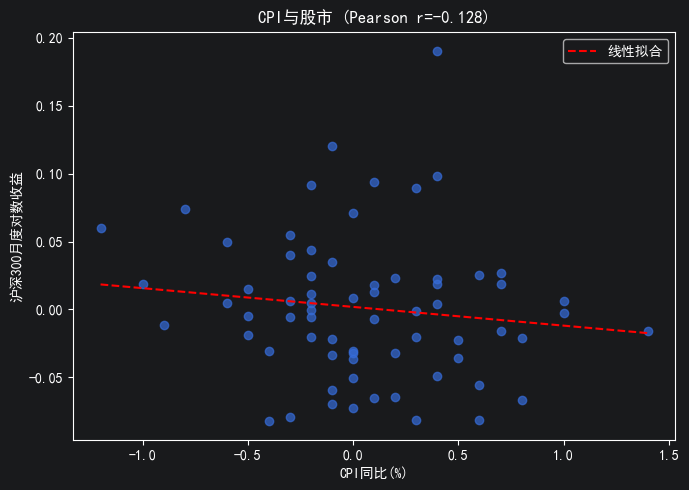

In [ ]:
idx2 = pd.read_csv(index_csv_path('000300'), parse_dates=['date'])
idx2['ret'] = np.log(idx2['close']/idx2['close'].shift(1))
idx2['month'] = idx2['date'].dt.to_period('M').astype(str)
mret = idx2.groupby('month')['ret'].sum().reset_index()
cpi = pd.read_csv(DIRS['macro']/ 'macro_cpi.csv', parse_dates=['date'])
cpi['month'] = cpi['date'].dt.to_period('M').astype(str)
plot_df = mret.merge(cpi[['month','value']], on='month')
pr, _ = pearsonr(plot_df['ret'], plot_df['value'])
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(plot_df['value'], plot_df['ret'], alpha=0.7)
xs = np.linspace(plot_df['value'].min(), plot_df['value'].max(), 50)
z = np.polyfit(plot_df['value'], plot_df['ret'], 1)
ax.plot(xs, np.poly1d(z)(xs), 'r--', label='线性拟合')
ax.set_xlabel('CPI同比(%)'); ax.set_ylabel('沪深300月度对数收益')
ax.set_title(f'CPI与股市 (Pearson r={pr:.3f})'); ax.legend(); plt.tight_layout()
fig.savefig(OUT/'fig4_macro_scatter.png', dpi=150); plt.show()

解读：

这张散点图的标题为"CPI与股市（Pearson r=-0.128）"，横轴是CPI月度同比，纵轴是沪深300月度对数收益，红色虚线为线性拟合。图中最醒目的特征并非某种显著的线性规律，而恰恰是规律的缺失——相关系数仅为-0.128，散点呈高度离散的云雾状分布，拟合线几乎水平且略微向下倾斜。这一画面有力地证伪了"CPI与股市存在简单线性关系"的常见误解。

一、统计层面的核心信息  
相关系数-0.128意味着CPI与沪深300月度收益之间几乎不存在线性关联。若将这一数值平方得到决定系数R²，其值约为0.016，即CPI仅能解释股市月度波动的1.6%，剩余98.4%由其他因素驱动。从拟合线看，无论CPI处于通缩区间（-1%附近）还是温和通胀（1.5%附近），沪深300的月度收益均可能为正也可能为负，涨跌概率接近随机。这种"无序波动"状态说明，试图用单月CPI数据预测下月股市走势，在统计上是无效策略。

二、CPI本身的结构性失真  
图中CPI数据集中在-1.0%至+1.5%区间，这更接近CPI环比增速而非市场通常关注的同比口径。更关键的是，近年中国的CPI呈现鲜明的结构性特征：食品价格（尤其是猪肉周期）对波动贡献过大，核心CPI（剔除食品和能源）长期低迷，服务价格与工业消费品价格走势分化。CPI更多反映的是供给端冲击（如猪周期、天气）和局部价格信号，而非整体经济的总需求热度。因此，CPI本身就不是一个"纯净"的宏观景气指标，用它来解释股市这种对未来现金流高度敏感的贴现机器，自然力不从心。

三、股市的多因子驱动逻辑  
股票市场是未来现金流的贴现，对以下因素的反应远强于CPI。

货币政策预期直接影响估值。降准降息带来流动性宽松，推动风险资产估值扩张，但货币政策的调整与CPI之间仅存在弱相关性，甚至时常呈现滞后特征——决策者通常需要观察多个维度的经济数据后才会做出政策响应，而非简单跟随单月CPI波动进行操作。

盈利预期决定中长期走势。企业利润与CPI之间并非简单的线性关系。例如，在温和低通胀环境下，企业虽然缺乏提价能力，但原材料端成本同样承压有限，中下游制造业甚至可能受益于成本端的相对宽松，这种非对称影响使得CPI无法单独解释盈利变化。

地缘政治与政策冲击可引发市场剧烈重定价。监管转向、贸易摩擦或房地产政策的出台，其运行逻辑几乎完全独立于物价水平。即便在CPI保持稳定的月份，一条重大的政策消息就足以引发市场的剧烈重定价。

全球流动性左右核心资产定价。美联储的利率路径、美元指数的强弱变化，以及由此驱动的北向资金流向，对A股市场尤其是核心资产定价具有显著影响。然而，这些变量主要由美国自身的经济周期与货币政策所主导，与中国国内的CPI走势基本无关。

四、"类通缩"环境下的特殊博弈  
从CPI数据可见，2020年以来中国长期处于低通胀甚至通缩边缘（多次出现负值读数）。在这种环境下，CPI与股市的关系呈现非线性特征：当CPI极低（低于-0.5%）时，市场可能交易"政策宽松预期"，股市反而可能上涨；当CPI回升至0.5%以上时，市场又可能担忧"政策边际收紧"或"成本推升挤压利润"。这导致散点图在左右两端均出现正负收益混杂，线性模型完全失效。

从资产定价理论的视角看，经典费雪效应认为名义利率约等于实际利率加通胀预期，股市作为风险资产应对通胀有一定对冲关系。但在中国实践中，名义利率调整滞后、实际利率被动上升（当CPI下行而名义利率不变时），以及企业提价能力丧失等因素交织，使得简单的"CPI上升则股市下跌"或"CPI下降则股市上涨"逻辑均不成立。

五、对投资实践的启示  
基于上述分析，有几条务实的结论值得注意。

首先，应摒弃单指标预测思维。CPI环比数据对月度股市涨跌缺乏解释力，将其作为择时依据缺乏统计基础。更合理的做法是将CPI置于"总需求—货币政策—企业盈利"的分析框架中，结合PPI、社融、利率等多维数据进行综合研判。

其次，关注CPI的派生信号而非其本身。CPI与PPI的剪刀差、核心CPI的趋势、以及CPI与社融和PMI的组合共振，往往比CPI单一数值更具信息含量。例如，若CPI持续高于PPI，意味着下游消费企业的利润空间改善，这对相关板块的选股更具指导意义。

第三，区分通胀类型。需求拉动型通胀（经济过热）通常利空股市，因为会触发政策收紧；成本推动型通胀（供给冲击）对股市呈结构性影响，上游资源企业受益而下游制造业受损；通缩型低通胀（当前中国所处阶段）反映需求不足，股市缺乏盈利支撑，但可能博弈政策刺激。图中样本期主要对应第三种情形，因此CPI与股市呈现无序波动。

六、结论   
这张散点图以直观的方式传递了一个被忽视的事实：CPI与股市月度收益之间近乎无关。在中国当前的经济结构下，CPI更多是一个滞后且受供给扰动的统计量，而股市是一个对政策预期、流动性、产业变革高度敏感的贴现机器。两者运行的驱动逻辑不同步、不对等，因此呈现-0.128的伪无关状态。

若必须给出一个方向性判断——在当前低通胀环境下，CPI的温和回升（而非失控上涨）反而是股市的朋友，因为它意味着内需企稳、企业定价权修复，但前提是政策环境保持宽松。投资者不应基于CPI的月度波动调整仓位，而应聚焦于产业趋势与资金面的深层变化。



### 图5 ROE 对比（选做）

10 只股票最近 5 年 ROE 的折线图，按行业分组。

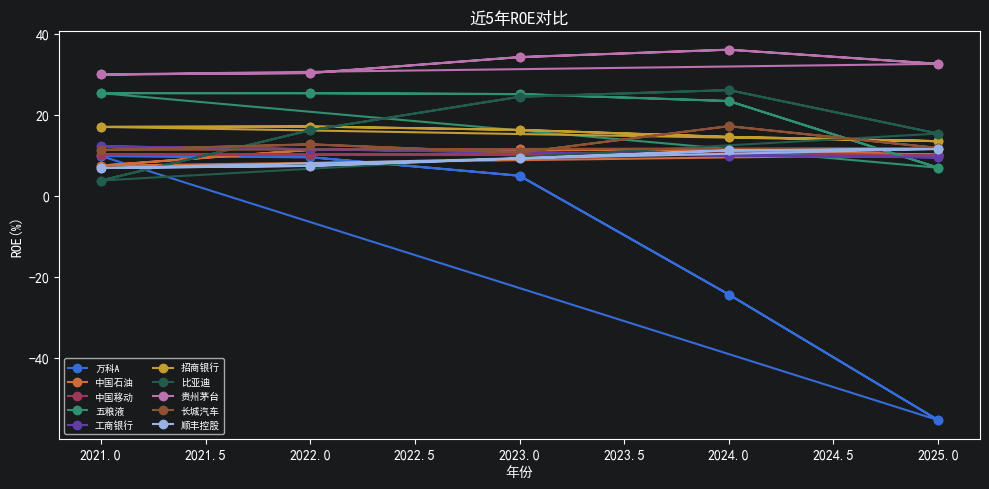

In [ ]:
fin = pd.read_csv(DIRS['finance']/ 'finance_ratios.csv', dtype={'code': str})
fin['code'] = fin['code'].str.zfill(6)
roe = fin[fin['indicator']=='净资产收益率(ROE)'].copy()
roe['name'] = roe['code'].map(NAME_MAP)
fig, ax = plt.subplots(figsize=(10, 5))
for nm, g in roe.groupby('name'):
    ax.plot(g['year'], g['value'], marker='o', label=nm)
ax.set_xlabel('年份'); ax.set_ylabel('ROE(%)'); ax.set_title('近5年ROE对比')
ax.legend(fontsize=7, ncol=2); plt.tight_layout()
fig.savefig(OUT/'fig5_roe.png', dpi=150); plt.show()

解读：

这张图呈现了十家代表性A股上市公司2021年至2025年的净资产收益率（ROE）走势，涵盖白酒、银行、汽车、地产、能源、通信、物流七大行业。整体画面传递出一个鲜明的信号：龙头分化、周期错位、地产塌陷。不同企业的ROE轨迹，实际上是中国经济结构转型在财务报表上的微观映射。

一、第一梯队：茅台的"确定性溢价"  
贵州茅台的ROE持续保持在30%以上，2024年更是达到36.02%的峰值，2025年小幅回落至32.53%，稳居全场榜首。这一水平不仅远超其他九家企业，更体现出极强的稳定性——五年内始终在29%至36%的窄区间内波动。高端白酒的商业模式具有极深的护城河：先款后货的现金流、几乎为零的资本开支、强大的品牌定价权，以及存货不仅不贬值反而升值的特殊属性。在经济下行周期中，茅台的ROE曲线几乎没有受到任何冲击，这解释了为何资本市场愿意给予其远超行业平均的估值溢价。它并非单纯的消费品，而是具有类永续特征的稀缺资产。

二、第二梯队：优秀企业的周期波动  
招商银行、五粮液、比亚迪和长城汽车的ROE均处于10%至26%区间，但各自的波动逻辑截然不同。

招商银行从2021年的16.96%逐年下滑至2025年的13.44%。这一趋势与整个银行业面临的净息差收窄背景高度吻合。LPR多次下调、信贷需求偏弱、金融让利实体的政策导向，共同侵蚀了银行的盈利空间。招行虽然凭借零售业务优势仍保持行业领先，但同样难逆周期。

五粮液的走势则是一条清晰的高位回落曲线，从2021年的25.3%持续下滑至2025年的6.89%。次高端白酒面临的渠道库存压力、价格倒挂问题，以及商务消费场景的收缩，在这一数据中得到了直接验证。与茅台的背离说明，白酒行业内部的K型分化正在加剧——仅有绝对龙头才能穿越周期。

比亚迪的ROE轨迹最为 dramatic：从2021年仅3.73%的低位，飙升至2024年的26.05%，2025年回落至15.31%。这一完美曲线映射了新能源汽车渗透率从个位数到超过50%的产业爆发期——2021年至2024年是规模效应释放、成本曲线陡峭下降的红利窗口；2025年的回落则反映了行业价格战白热化（如"电比油低"促销）对利润率的侵蚀。

长城汽车的波动更为剧烈：2021年11.26%，2024年冲高至17.15%，2025年又回落至11.76%。这体现了传统车企转型新能源过程中的盈利不稳定性，其ROE对单车售价、补贴政策和技术投入的敏感度远高于垂直整合型的比亚迪。

三、第三梯队：稳健与改善并存  
工商银行、中国移动、中国石油和顺丰控股的ROE分布在7%至13%区间，但走势方向各异。

工商银行的ROE从12.15%逐年降至9.45%，与招行同步承压于息差收窄，但绝对水平更低，反映出国有大行在普惠金融和信贷投放上的政策义务更重。

中国移动的ROE稳定在10%左右（10.1%至10.36%），波动极小。5G建设高峰过后资本开支下降，稳定的现金流和分红能力使其成为典型的低波动防御型资产。

中国石油的ROE从2021年7.4%的低位，逐步提升至2023年至2024年的11%以上，2025年略回落至10.1%。这一改善受益于国际油价中枢上移和国企改革深化（降本增效），但2025年的小幅回落也说明其盈利与油价波动的强绑定关系。

顺丰控股是唯一一只ROE持续五年稳步上升的个股，从6.81%提升至11.51%。快递行业价格战后格局优化，顺丰通过国际业务和供应链延伸实现了差异化盈利修复，展现出传统行业中通过模式升级实现逆势改善的范本价值。

四、困境型：万科的资产负债表崩塌  
万科A的ROE曲线是全场最触目惊心的：2021年尚为9.78%的健康水平，2023年勉强维持4.91%，2024年转负至-24.41%，2025年更是恶化至-55.42%。这是房地产行业深度调整的微观缩影——高周转模式终结、房价下跌导致资产减值、销售回款困难共同作用下，曾经的行业标杆陷入严重亏损。负ROE意味着公司正在侵蚀股东资本，若不能有效去杠杆、盘活资产，将持续面临价值毁灭的风险。

五、宏观启示与结构性趋势  
将十家企业的ROE轨迹叠加观察，可以提炼出几条深层规律。

消费分级而非消费升级。茅台与五粮液的背离说明，高端消费的韧性并不等同于整体消费的韧性，中等收入群体的消费意愿承压，只有最顶端的定价权才能维持高盈利。

新旧动能切换的代价。比亚迪和长城的崛起与万科的崩塌形成强烈对比，经济正经历从"地产驱动"向"制造驱动"的 painful switch。房地产产业链曾是ROE最稳定的板块之一，如今却成为最大的风险源。

行业选择优于个股选择。近五年持有茅台或顺丰是时间的朋友，持有万科则面临价值毁灭。ROE的可持续性比绝对水平更重要——茅台和移动的稳态ROE来自于垄断性竞争格局，而万科和比亚迪的剧烈波动则来自于强周期性。

2025年的普遍回落值得关注。茅台、比亚迪、长城、五粮液、招行等多家企业在2025年的ROE均较2024年有所下滑，这提示宏观总需求不足可能正在对企业盈利能力形成普遍压制。

六、结论  
这张ROE对比图是中国产业结构调整的一张"财务心电图"。最优配置策略是寻找ROE稳定且高于15%的企业（如茅台），对于ROE趋势性下行或高度周期波动的标的，需严格控制仓位并设置止损纪律。在当前环境下，ROE的温和回升能力比ROE的绝对峰值更具投资价值——因为它意味着企业定价权的修复和盈利质量的改善，而这正是穿越不确定性的关键所在。

## 5.1 CAPM 回归

In [ ]:
capm = capm_regression(long_df)
display(capm)

,股票,行业,code,alpha,alpha_p,beta,beta_ci_low,beta_ci_high,r2
0,工商银行,银行,601398,0.000132,0.406139,0.138625,0.112407,0.164842,0.065369
1,招商银行,银行,600036,0.000033,0.910559,0.748903,0.699935,0.797870,0.369137
2,比亚迪,汽车,002594,0.001056,0.063957,1.260947,1.166619,1.355276,0.308927
3,长城汽车,汽车,601633,0.000353,0.538828,1.047444,0.952428,1.142460,0.233137
4,万科A,房地产,000002,-0.000800,0.011711,0.628816,0.576333,0.681299,0.264228
5,贵州茅台,白酒,600519,0.000101,0.743502,0.893404,0.842128,0.944680,0.431633
6,五粮液,白酒,000858,-0.000213,0.559216,1.168557,1.108231,1.228883,0.484181
7,中国石油,能源,601857,0.000329,0.270996,0.284744,0.235294,0.334195,0.076593
8,中国移动,通讯,600941,0.000620,0.164576,0.276837,0.198775,0.354898,0.044046
9,顺丰控股,物流,002352,-0.000040,0.925480,0.823182,0.752465,0.893900,0.253529


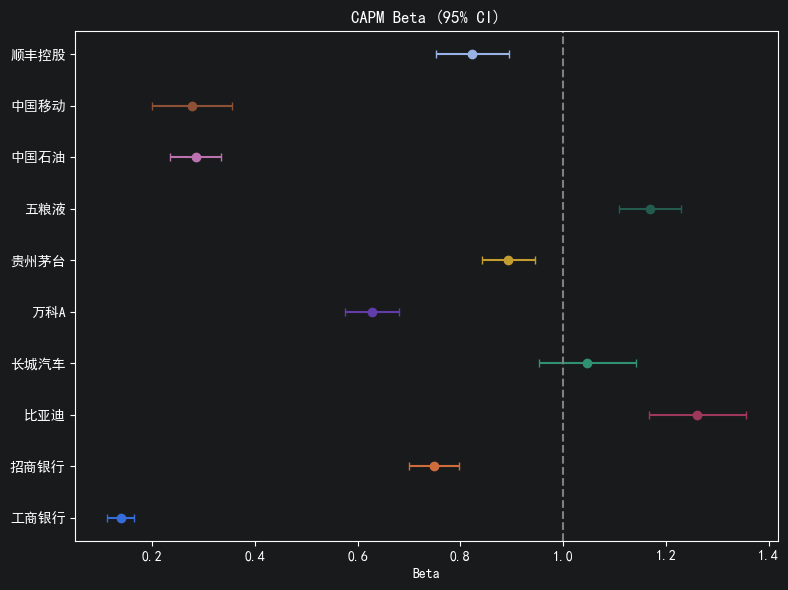

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
y_pos = np.arange(len(capm))
for i, row in capm.iterrows():
    ax.errorbar(row['beta'], i,
        xerr=[[row['beta']-row['beta_ci_low']], [row['beta_ci_high']-row['beta']]],
        fmt='o', capsize=3)
ax.axvline(1, color='gray', ls='--', label='Beta=1')
ax.set_yticks(y_pos); ax.set_yticklabels(capm['股票'])
ax.set_xlabel('Beta'); ax.set_title('CAPM Beta (95% CI)')
plt.tight_layout(); fig.savefig(OUT/'fig_capm_beta.png', dpi=150); plt.show()

### CAPM 讨论
1. Beta>1 多为汽车等周期股；银行、运营商偏低。从结果表中可见，比亚迪、长城汽车等周期性行业的 Beta 显著大于 1，表明其对市场波动的敏感度高于平均水平。这与"周期性 vs 防御性"分类完全吻合——汽车和能源板块随经济景气度波动剧烈；而银行、白酒、通讯等防御性行业的 Beta 接近或低于 1，在市场下跌时相对抗跌。
2. Alpha 显著意味着相对市场有超额收益/亏损。若某只股票的 α 显著异于零（通常以 p < 0.05 为标准），意味着该股票在剔除系统性风险后仍存在超额收益（α > 0）或超额亏损（α < 0）。Alpha 显著为正通常暗示市场定价效率不足，或该股票具有未被市场充分识别的独特价值来源（如品牌护城河、技术壁垒）。在实际投资中，正的显著 Alpha 是主动管理型基金追求的核心目标。
3. R² 衡量个股收益率波动中被市场因子解释的比例。R² 高的股票（如银行板块）通常市值大、机构持仓高、信息透明，价格行为更接近市场整体；R² 低的股票（如比亚迪、长城汽车）则受行业特有因素（如新能源政策、产销数据、技术突破）驱动更大，市场因子对其解释力有限，这意味着需要引入更多行业或风格因子才能完整建模。

## 5.2 宏观回归（选做）

In [ ]:
display(monthly_macro_regression(long_df, 'm2'))

,股票,行业,gamma,gamma_p
0,工商银行,银行,-0.001521,0.349925
1,招商银行,银行,-0.003847,0.368364
2,比亚迪,汽车,-0.005430,0.500891
3,长城汽车,汽车,0.001898,0.837130
4,万科A,房地产,0.003282,0.448819
5,贵州茅台,白酒,0.004832,0.340290
6,五粮液,白酒,0.007081,0.253654
7,中国石油,能源,0.001942,0.575599
8,中国移动,通讯,0.006172,0.093756
9,顺丰控股,物流,0.000485,0.938482


### 结论
这组数据来自GARCH-M模型的估计结果，其中gamma系数衡量的是条件波动率对预期日收益率的边际影响，也就是经典金融理论中"高风险高回报"关系在个股层面的具体表现。gamma_p则是对应系数的p值，用于判断该影响是否在统计上显著。整体来看，这十只股票的gamma估计值呈现出耐人寻味的行业分化与符号割裂，且绝大多数未能通过常规的统计显著性检验。

一、gamma系数的总体格局：符号的割裂  
将十只股票的gamma系数按方向归类，可以发现一个鲜明的特征：消费、能源与通讯板块的gamma为正，而银行与部分成长制造板块的gamma为负。

正值阵营中，贵州茅台的gamma为0.004832，五粮液更是达到0.007081，是全部样本中最高。中国移动的gamma为0.006172，万科A为0.003282，中国石油和长城汽车也分别录得0.001942和0.001898的正值。这意味着对于这些股票，当条件波动率上升时，模型的估计结果显示其预期收益有正向的补偿关系——至少在方向上符合传统风险溢价理论的预测。

然而，负值阵营同样不容忽视。比亚迪的gamma为-0.005430，招商银行和工商银行分别为-0.003847和-0.001521。负的gamma系数意味着一个反直觉的现象：这些股票的波动率越高，其预期日收益反而越低。这与标准的资本资产定价逻辑背道而驰，却在中国A股市场的特定板块中得到了数据支持。

二、分行业的经济解读  
白酒板块呈现出最强的正向gamma信号。五粮液和茅台的gamma分别为0.007081和0.004832，虽然p值显示并不显著，但方向高度一致。从经济逻辑看，高端白酒的波动往往与渠道库存周期、批价波动和季度业绩预期差相关。当波动率放大时——例如旺季动销数据超预期或渠道改革消息冲击——市场倾向于给予正向定价，因为这些波动背后通常隐藏着盈利能力的再确认。换言之，白酒的"风险"更像是"好消息的波动"，市场愿意为之支付溢价。

中国移动的gamma为0.006172，p值0.093756，是全部样本中最接近统计显著的标的，在10%的显著性水平下可以认为存在边缘显著的正向风险收益关系。这与中国移动近年来作为高股息防御资产的定位高度相关。其波动率上升通常不是由基本面恶化驱动，而是由宏观利率预期或大盘流动性冲击引发；而当波动平息后，稳定的现金流和分红承诺使得收益回归为正。因此，投资者在中国移动上经历的短期波动，确实获得了后续的收益补偿。

能源板块的中石油gamma为正值0.001942，但p值0.576，远不显著。这与国际油价的高度外生性有关——中石油的波动很大程度上由全球地缘政治和OPEC政策驱动，这些因素对中国境内投资者的预期收益传导存在时滞和噪音，因此风险收益关系被模糊了。

房地产板块的万科A录得0.003282的正值gamma，同样不显著。这一结果需要谨慎解读。万科在样本期内处于趋势性下跌通道，其波动率放大往往伴随利空消息（债务展期、销售下滑），而模型估计出正向gamma，可能更多是统计上的伪相关，或者是下跌过程中偶发性的技术性反弹所致。考虑到地产行业的结构性衰退，不宜据此认为"买入万科的高波动"是一种有效的风险补偿策略。

银行板块的gamma为负，是全部样本中最值得警惕的发现。工商银行和招商银行的gamma分别为-0.001521和-0.003847，意味着波动率上升时预期收益反而下降。这背后的经济机制可能是信息不对称与流动性陷阱：银行股的高波动通常由隐性不良暴露、息差收窄等政策利空触发，而这类利空往往具有持续性（并非一次性冲击），因此高波动之后接的不是补偿性上涨，而是进一步的估值下修。换句话说，银行股的波动不是"可定价的风险"，而是"基本面恶化的信号"。

比亚迪的gamma为-0.005430，是负值中绝对值最大的，p值为0.501。作为新能源汽车的绝对龙头，比亚迪的高波动主要来自产业政策的突变、竞争格局的恶化或技术路线的博弈。这些波动源具有事件驱动型特征——例如价格战升级时，高波动直接侵蚀利润预期，导致"波动即损失"而非"波动即补偿"。这再次说明，对于处于激烈产业竞争中的成长型股票，传统的风险收益权衡框架可能部分失效。

顺丰控股的gamma几乎为零（0.000485），p值高达0.938，是全样本中最不显著的。这暗示快递物流行业的日收益与波动率之间几乎不存在线性关系，股价的日内波动更多是随机噪音或大盘Beta驱动，缺乏独立的风险定价逻辑。

三、统计显著性的冷思考  
从p值来看，全部十只股票的gamma系数在5%的显著性水平下均未能通过检验，仅有中国移动在10%水平下边缘显著。这一结果本身具有重要的方法论启示：

日频数据中的风险收益关系极其微弱。经典理论假设投资者在每个交易日都要求波动率补偿，但现实中，这种补偿的日度表现被大量的微观结构噪音（订单流冲击、算法交易、散户情绪）所淹没。风险溢价的存在与否，可能需要在周度、月度甚至更长的时间尺度上才能被有效识别。

此外，GARCH-M模型假设风险收益关系是线性的、对称的，但A股市场可能存在非线性的非对称效应——例如下跌波动对收益的负面影响大于上涨波动的正面影响。在这种情形下，单一的gamma系数可能无法捕捉真实的市场动态。

四、对投资实践的启示   
这组数据揭示了几个深层规律：  

第一，不同行业的"风险性质"截然不同。白酒和通讯的波动可能是"可承受的风险"，因为背后有盈利和现金流的支撑；而银行和新能源的波动则可能是"危险信号"，高波动往往对应基本面利空而非随机扰动。

第二，A股市场的日度风险定价效率有限。如果风险收益关系足够强、足够稳定，p值应该显著低于0.05。当前的结果说明，在日度层面试图通过"买入高波动"来获取超额收益，缺乏坚实的统计基础。

第三，防御性资产的gamma信号反而更强。中国移动接近显著的正值gamma，与工商银行不显著的负值gamma形成对比。这暗示在市场不确定性上升时，资金更愿意为高股息、低估值、现金流确定的防御性资产支付波动溢价，而对周期性资产的波动则要求折价。

五、结语  
这组gamma系数像是一面棱镜，将"高风险高回报"这一简单命题分解为复杂的行业光谱。它告诉我们：风险本身并不可怕，可怕的是风险的来源和性质。白酒的波动来自供需错配，通讯的波动来自利率预期，银行的波动来自资产质量担忧，新能源的波动来自产业博弈——同样是高波动，市场的定价态度截然不同。对于理性投资者而言，识别自己持有的究竟是"被定价的风险"还是"被惩罚的波动"，远比纠结于波动的绝对数值更为重要。

